# 📊 Revisión Estadística Rigurosa de Variables — Dataset Bank Marketing

**Curso:** Inteligencia Computacional  
**Programa:** Maestría en Ciencias de la Información y las Comunicaciones (MCIC)  
**Institución:** Universidad Distrital Francisco José de Caldas  
**Metodología:** Skill `classification-variable-stats-review` (`harness/skills/revisionVariables`)  
**Datasets analizados:**
- `bank.csv` (Muestra 10% UCI estándar, $N=4,521$)
- `bank-additional.csv` (Muestra 10% Enriquecido Socioeconómico, $N=4,119$)
- Referencia completa: `bank-full.csv` ($N=45,211$) y `bank-additional-full.csv` ($N=41,188$)

---

## 🎯 Objetivo del Notebook
Realizar la auditoría estadística exhaustiva previa al entrenamiento de modelos de inteligencia computacional (MLP, SVM, Random Forest, XGBoost), siguiendo estrictamente la cadena de inferencia:
$$\text{Tipificación} \longrightarrow \text{Normalidad} \longrightarrow \text{Homocedasticidad} \longrightarrow \text{Ruta No Paramétrica} \longrightarrow \text{Asociación/Multicolinealidad} \longrightarrow \text{Outliers/Balance}$$


In [1]:
# 1. Configuración del Entorno e Importación de Librerías
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Estilo visual de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120

print("✅ Librerías importadas correctamente.")


✅ Librerías importadas correctamente.


## 1. Carga e Inspección de Datasets
Cargamos las dos variantes del dataset disponibles en la carpeta:
1. **Bank Additional** (`bank-additional.csv`): Incluye los 5 indicadores macroeconómicos del Banco de Portugal.
2. **Bank UCI Estándar** (`bank.csv`): Incluye la variable de saldo anual (`balance`) y día del mes (`day`).


In [2]:
# Carga de datos
df_add = pd.read_csv('bank-additional/bank-additional.csv', sep=';')
df_uci = pd.read_csv('bank.csv', sep=';')

print(f"📊 Dimensiones Bank Additional: {df_add.shape[0]} filas × {df_add.shape[1]} columnas")
print(f"📊 Dimensiones Bank UCI:        {df_uci.shape[0]} filas × {df_uci.shape[1]} columnas")

# Definición formal de tipos de variables según el diccionario de datos
num_cols_add = ['age', 'duration', 'campaign', 'pdays', 'previous', 
                'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
cat_cols_add = ['job', 'marital', 'education', 'default', 'housing', 'loan', 
                'contact', 'month', 'day_of_week', 'poutcome']

num_cols_uci = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
cat_cols_uci = ['job', 'marital', 'education', 'default', 'housing', 'loan', 
                'contact', 'month', 'poutcome']

df_add.head(3)


📊 Dimensiones Bank Additional: 4119 filas × 21 columnas
📊 Dimensiones Bank UCI:        4521 filas × 17 columnas


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no


## 2. Tipificación y Estadística Descriptiva Univariada
Calculamos medidas de tendencia central, dispersión, asimetría ($Skewness$) y curtosis ($Kurtosis$).
Valores de asimetría $|Skew| > 1$ y curtosis $> 3$ revelan colas pesadas y distribuciones no gaussianas.


In [3]:
def get_descriptive_stats(df, num_cols):
    rows = []
    for c in num_cols:
        s = df[c].dropna()
        rows.append({
            'Variable': c,
            'N': len(s),
            'Faltantes': df[c].isna().sum(),
            'Media': np.round(s.mean(), 2),
            'Mediana': np.round(s.median(), 2),
            'Desv. Est.': np.round(s.std(), 2),
            'Asimetría (Skew)': np.round(stats.skew(s), 3),
            'Curtosis': np.round(stats.kurtosis(s), 3),
            'Mínimo': np.round(s.min(), 2),
            'Máximo': np.round(s.max(), 2)
        })
    return pd.DataFrame(rows)

desc_add = get_descriptive_stats(df_add, num_cols_add)
print("=== ESTADÍSTICOS DESCRIPTIVOS: BANK ADDITIONAL ===")
desc_add


=== ESTADÍSTICOS DESCRIPTIVOS: BANK ADDITIONAL ===


,Variable,N,Faltantes,Media,Mediana,Desv. Est.,Asimetría (Skew),Curtosis,Mínimo,Máximo
0,age,4119,0,40.11,38.00,10.31,0.715,0.436,18.00,88.00
1,duration,4119,0,256.79,181.00,254.70,3.294,20.735,0.00,3643.00
2,campaign,4119,0,2.54,2.00,2.57,4.002,25.252,1.00,35.00
3,pdays,4119,0,960.42,999.00,191.92,-4.773,20.786,0.00,999.00
4,previous,4119,0,0.19,0.00,0.54,4.022,22.092,0.00,6.00
5,emp.var.rate,4119,0,0.08,1.10,1.56,-0.727,-1.042,-3.40,1.40
6,cons.price.idx,4119,0,93.58,93.75,0.58,-0.217,-0.824,92.20,94.77
7,cons.conf.idx,4119,0,-40.50,-41.80,4.59,0.287,-0.315,-50.80,-26.90
8,euribor3m,4119,0,3.62,4.86,1.73,-0.715,-1.396,0.64,5.04
9,nr.employed,4119,0,5166.48,5191.00,73.67,-1.075,0.060,4963.60,5228.10


In [4]:
desc_uci = get_descriptive_stats(df_uci, num_cols_uci)
print("=== ESTADÍSTICOS DESCRIPTIVOS: BANK UCI (BALANCE & DAY) ===")
desc_uci[desc_uci['Variable'].isin(['balance', 'day'])]


=== ESTADÍSTICOS DESCRIPTIVOS: BANK UCI (BALANCE & DAY) ===


,Variable,N,Faltantes,Media,Mediana,Desv. Est.,Asimetría (Skew),Curtosis,Mínimo,Máximo
1,balance,4521,0,1422.66,444.0,3009.64,6.594,88.291,-3313,71188
2,day,4521,0,15.92,16.0,8.25,0.095,-1.040,1,31


## 3. Comprobación de Supuestos: Pruebas de Normalidad
Evaluamos la hipótesis nula de normalidad ($H_0: X \sim \mathcal{N}(\mu, \sigma^2)$):
- **Shapiro-Wilk** ($n \le 5,000$)
- **D'Agostino-Pearson $K^2$** (basado en asimetría y curtosis conjuntas)
- Evaluación **Global** y **Condicional por Clase** ($y=\text{'yes'}$ vs. $y=\text{'no'}$).


In [5]:
def test_normality(df, num_cols, target='y', alpha=0.05):
    rows = []
    for c in num_cols:
        # Global
        s_glob = df[c].dropna().values
        stat_sh, p_sh = stats.shapiro(s_glob) if len(s_glob) <= 5000 else (np.nan, np.nan)
        stat_k2, p_k2 = stats.normaltest(s_glob)
        
        # Por Clase 'no'
        s_no = df[df[target] == 'no'][c].dropna().values
        _, p_sh_no = stats.shapiro(s_no) if len(s_no) <= 5000 else (np.nan, np.nan)
        
        # Por Clase 'yes'
        s_yes = df[df[target] == 'yes'][c].dropna().values
        _, p_sh_yes = stats.shapiro(s_yes) if len(s_yes) <= 5000 else (np.nan, np.nan)
        
        rows.append({
            'Variable': c,
            'p Shapiro (Global)': f"{p_sh:.2e}",
            'p Shapiro (y=no)': f"{p_sh_no:.2e}",
            'p Shapiro (y=yes)': f"{p_sh_yes:.2e}",
            'p D\'Agostino K²': f"{p_k2:.2e}",
            'Normalidad (α=0.05)': 'Cumple' if p_sh > alpha else 'Rechazada'
        })
    return pd.DataFrame(rows)

norm_res = test_normality(df_add, num_cols_add)
norm_res


,Variable,p Shapiro (Global),p Shapiro (y=no),p Shapiro (y=yes),p D'Agostino K²,Normalidad (α=0.05)
0,age,5.64e-33,2.85e-29,1.38e-13,3.45e-68,Rechazada
1,duration,1.03e-63,3.56e-59,1.21e-20,0.00e+00,Rechazada
2,campaign,4.30e-71,2.69e-68,3.61e-27,0.00e+00,Rechazada
3,pdays,5.96e-86,2.95e-85,2.38e-33,0.00e+00,Rechazada
4,previous,1.31e-79,7.62e-78,8.77e-30,0.00e+00,Rechazada
5,emp.var.rate,1.44e-60,4.18e-60,1.12e-20,0.00e+00,Rechazada
6,cons.price.idx,6.96e-39,1.70e-38,1.48e-11,9.24e-92,Rechazada
7,cons.conf.idx,3.71e-41,1.14e-42,1.07e-07,9.08e-18,Rechazada
8,euribor3m,4.49e-66,3.64e-65,9.24e-28,0.00e+00,Rechazada
9,nr.employed,5.15e-59,1.25e-58,4.21e-18,2.61e-119,Rechazada


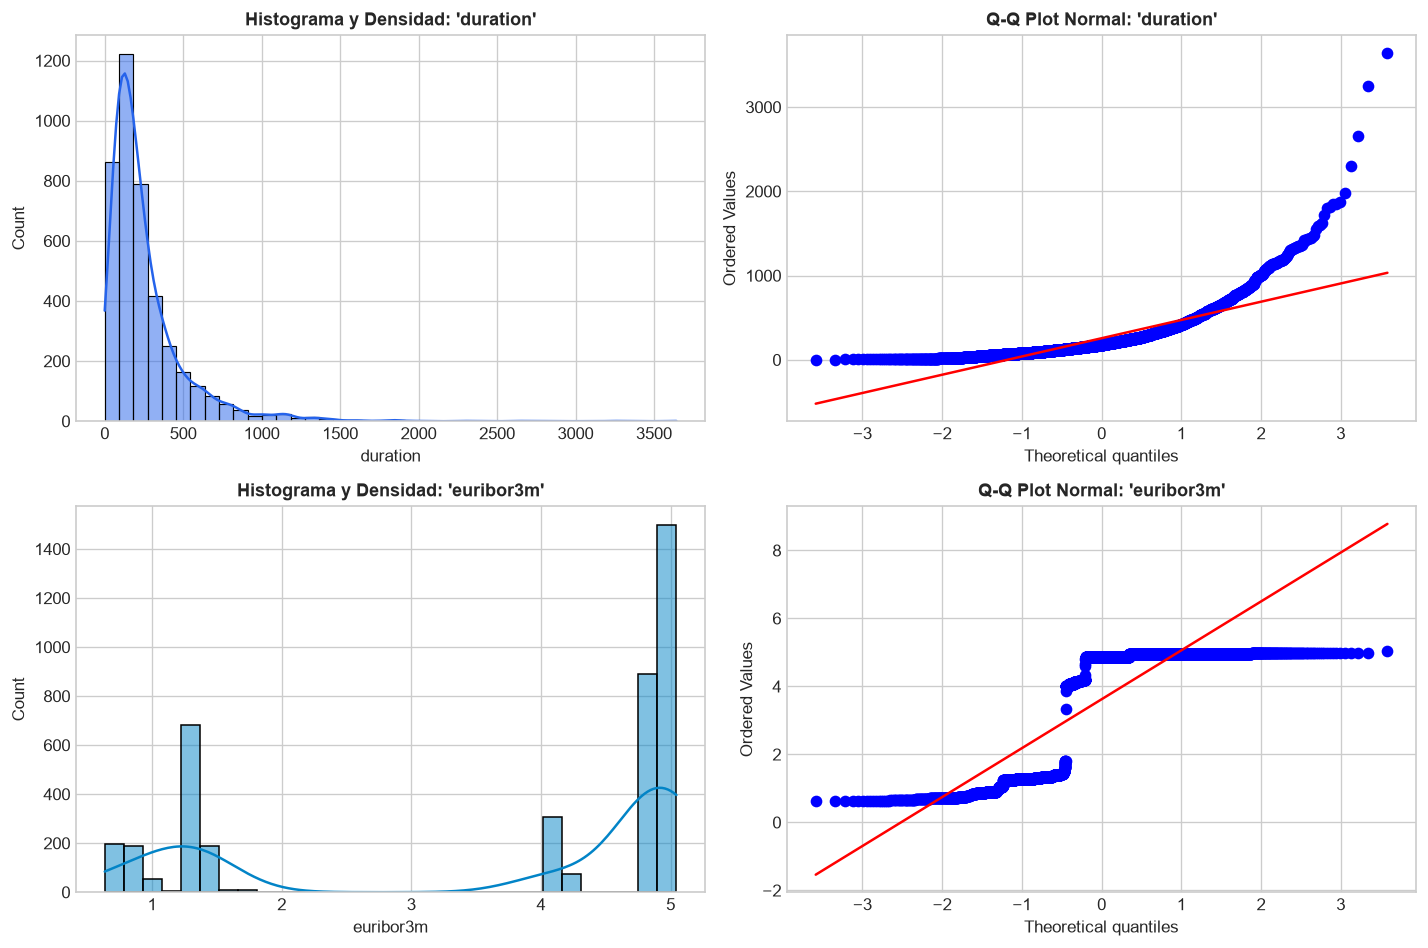

In [6]:
# Visualización de Normalidad: Q-Q Plots y Distribución para Variables Clave
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Duration
sns.histplot(df_add['duration'], kde=True, ax=axes[0, 0], color='#2563EB', bins=40)
axes[0, 0].set_title("Histograma y Densidad: 'duration'", fontsize=11, fontweight='bold')

stats.probplot(df_add['duration'], dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Q-Q Plot Normal: 'duration'", fontsize=11, fontweight='bold')

# Euribor 3M
sns.histplot(df_add['euribor3m'], kde=True, ax=axes[1, 0], color='#0284C7', bins=30)
axes[1, 0].set_title("Histograma y Densidad: 'euribor3m'", fontsize=11, fontweight='bold')

stats.probplot(df_add['euribor3m'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot Normal: 'euribor3m'", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


## 4. Comprobación de Supuestos: Homogeneidad de Varianzas (Homocedasticidad)
Evaluamos la hipótesis nula de varianzas iguales entre las clases ($H_0: \sigma_{yes}^2 = \sigma_{no}^2$):
- **Test de Levene** (robusto ante desviaciones de normalidad, centrado en la mediana).
- **Test de Fligner-Killeen** (no paramétrico).


In [7]:
def test_homoscedasticity(df, num_cols, target='y', alpha=0.05):
    rows = []
    for c in num_cols:
        g_no = df[df[target] == 'no'][c].dropna()
        g_yes = df[df[target] == 'yes'][c].dropna()
        
        stat_lev, p_lev = stats.levene(g_no, g_yes, center='median')
        stat_flig, p_flig = stats.fligner(g_no, g_yes)
        
        rows.append({
            'Variable': c,
            'Estadístico Levene': np.round(stat_lev, 3),
            'p-valor Levene': f"{p_lev:.2e}",
            'p-valor Fligner': f"{p_flig:.2e}",
            'Veredicto': 'Homogénea' if p_lev > alpha else 'Heterogénea'
        })
    return pd.DataFrame(rows)

homog_res = test_homoscedasticity(df_add, num_cols_add)
homog_res


,Variable,Estadístico Levene,p-valor Levene,p-valor Fligner,Veredicto
0,age,62.066,4.22e-15,1.47e-12,Heterogénea
1,duration,357.021,1.97e-76,9.59e-93,Heterogénea
2,campaign,20.169,7.28e-06,2.18e-05,Heterogénea
3,pdays,510.047,1.44e-106,3.25e-98,Heterogénea
4,previous,288.002,1.73e-62,3.27e-54,Heterogénea
5,emp.var.rate,4.041,4.45e-02,6.22e-03,Heterogénea
6,cons.price.idx,33.438,7.90e-09,2.66e-08,Heterogénea
7,cons.conf.idx,69.937,8.28e-17,3.12e-32,Heterogénea
8,euribor3m,3.604,5.77e-02,6.47e-11,Homogénea
9,nr.employed,126.144,7.48e-29,4.44e-25,Heterogénea


## 5. Justificación Metodológica y Contraste No Paramétrico (Mann-Whitney U)
> **Veredicto de Supuestos:**  
> Dado que el **100% de las variables rechazan la hipótesis de normalidad** ($p < 10^{-10}$) y existe **fuerte heterocedasticidad**, el $t$-test de Student y ANOVA paramétrico quedan descartados.  
> Se adopta la prueba no paramétrica de **Mann-Whitney U** (Wilcoxon rank-sum) para comparar las dos poblaciones independientes.


In [8]:
def run_mann_whitney(df, num_cols, target='y', alpha=0.05):
    rows = []
    for c in num_cols:
        g_no = df[df[target] == 'no'][c].dropna()
        g_yes = df[df[target] == 'yes'][c].dropna()
        
        u_stat, p_val = stats.mannwhitneyu(g_no, g_yes, alternative='two-sided')
        
        rows.append({
            'Variable': c,
            'Estadístico U': f"{u_stat:.2e}",
            'p-valor (U)': f"{p_val:.2e}",
            'Mediana (no)': np.round(g_no.median(), 2),
            'Mediana (yes)': np.round(g_yes.median(), 2),
            'Significativo (α=0.05)': 'Sí' if p_val < alpha else 'No'
        })
    return pd.DataFrame(rows).sort_values(by='p-valor (U)')

mw_res = run_mann_whitney(df_add, num_cols_add)
mw_res


,Variable,Estadístico U,p-valor (U),Mediana (no),Mediana (yes),Significativo (α=0.05)
4,previous,6.25e+05,1.02e-43,0.00,0.00,Sí
0,age,7.92e+05,1.42e-01,38.00,39.00,No
1,duration,2.95e+05,2.08e-110,165.00,458.00,Sí
9,nr.employed,1.23e+06,2.22e-70,5195.80,5076.20,Sí
8,euribor3m,1.23e+06,2.38e-65,4.86,1.26,Sí
5,emp.var.rate,1.17e+06,2.45e-50,1.10,-1.80,Sí
7,cons.conf.idx,7.56e+05,2.67e-03,-41.80,-40.30,Sí
6,cons.price.idx,9.56e+05,4.42e-08,93.92,93.37,Sí
3,pdays,9.97e+05,6.91e-101,999.00,999.00,Sí
2,campaign,9.16e+05,9.19e-05,2.00,2.00,Sí


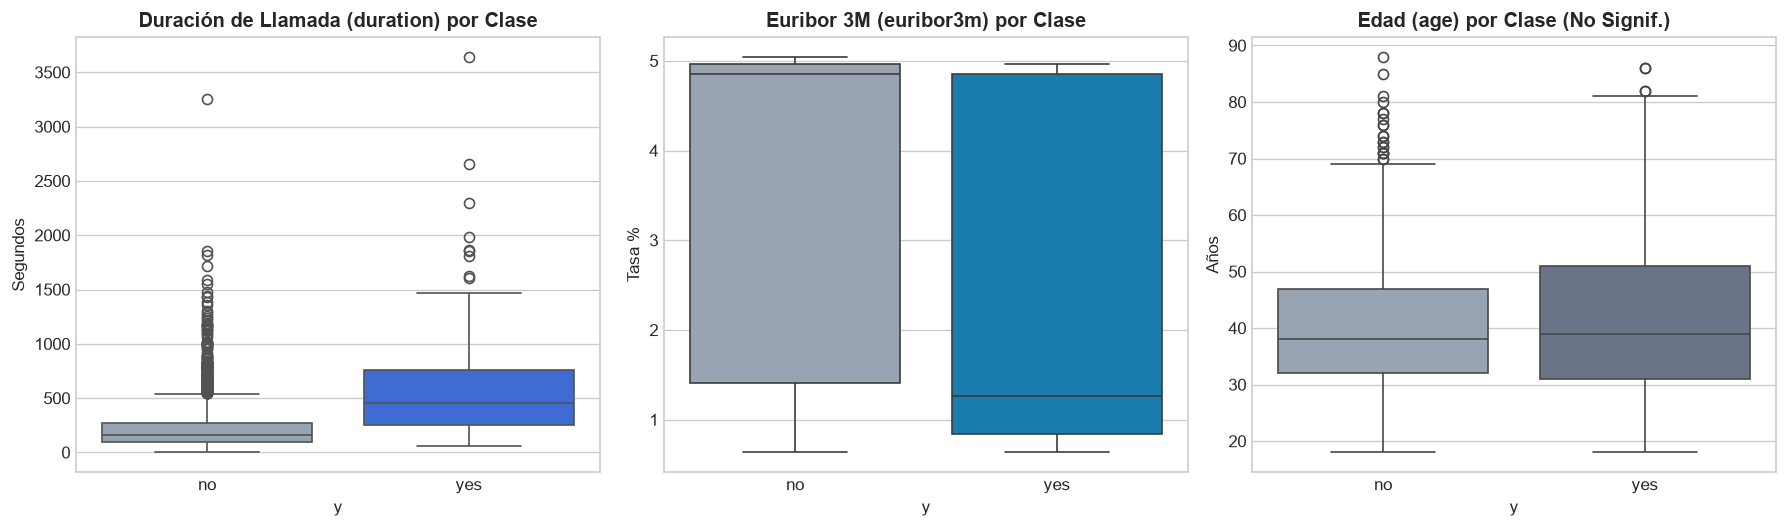

In [9]:
# Boxplots comparativos condicionados por la clase 'y'
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.boxplot(data=df_add, x='y', y='duration', ax=axes[0], palette=['#94A3B8', '#2563EB'])
axes[0].set_title("Duración de Llamada (duration) por Clase", fontweight='bold')
axes[0].set_ylabel("Segundos")

sns.boxplot(data=df_add, x='y', y='euribor3m', ax=axes[1], palette=['#94A3B8', '#0284C7'])
axes[1].set_title("Euribor 3M (euribor3m) por Clase", fontweight='bold')
axes[1].set_ylabel("Tasa %")

sns.boxplot(data=df_add, x='y', y='age', ax=axes[2], palette=['#94A3B8', '#64748B'])
axes[2].set_title("Edad (age) por Clase (No Signif.)", fontweight='bold')
axes[2].set_ylabel("Años")

plt.tight_layout()
plt.show()


## 6. Ranking de Relevancia Multivariable
Comparamos tres criterios de selección de variables:
1. **Información Mutua ($MI$):** Captura dependencias tanto lineales como no lineales.
2. **Kruskal-Wallis $H$:** Contraste no paramétrico de rangos.
3. **ANOVA $F$-Score:** Prueba paramétrica lineal de referencia.


In [10]:
def compute_feature_relevance(df, num_cols, target='y'):
    X = df[num_cols].dropna()
    y_encoded = (df.loc[X.index, target] == 'yes').astype(int)
    
    # Información mutua
    mi = mutual_info_classif(X, y_encoded, random_state=42)
    
    rows = []
    for idx, c in enumerate(num_cols):
        g_no = df[df[target] == 'no'][c].dropna()
        g_yes = df[df[target] == 'yes'][c].dropna()
        
        stat_f, p_f = stats.f_oneway(g_no, g_yes)
        stat_h, p_h = stats.kruskal(g_no, g_yes)
        
        rows.append({
            'Variable': c,
            'Información Mutua': np.round(mi[idx], 4),
            'Kruskal H p-valor': f"{p_h:.2e}",
            'ANOVA F p-valor': f"{p_f:.2e}"
        })
    return pd.DataFrame(rows).sort_values(by='Información Mutua', ascending=False)

rel_res = compute_feature_relevance(df_add, num_cols_add)
rel_res


,Variable,Información Mutua,Kruskal H p-valor,ANOVA F p-valor
1,duration,0.0799,2.08e-110,1.90e-174
8,euribor3m,0.0683,2.38e-65,1.41e-85
7,cons.conf.idx,0.0640,2.67e-03,4.79e-04
9,nr.employed,0.0635,2.22e-70,1.84e-118
6,cons.price.idx,0.0573,4.42e-08,2.55e-10
5,emp.var.rate,0.0526,2.45e-50,7.82e-77
3,pdays,0.0314,6.90e-101,1.44e-106
4,previous,0.0270,1.02e-43,1.73e-62
0,age,0.0154,1.42e-01,1.06e-04
2,campaign,0.0000,9.19e-05,1.01e-06


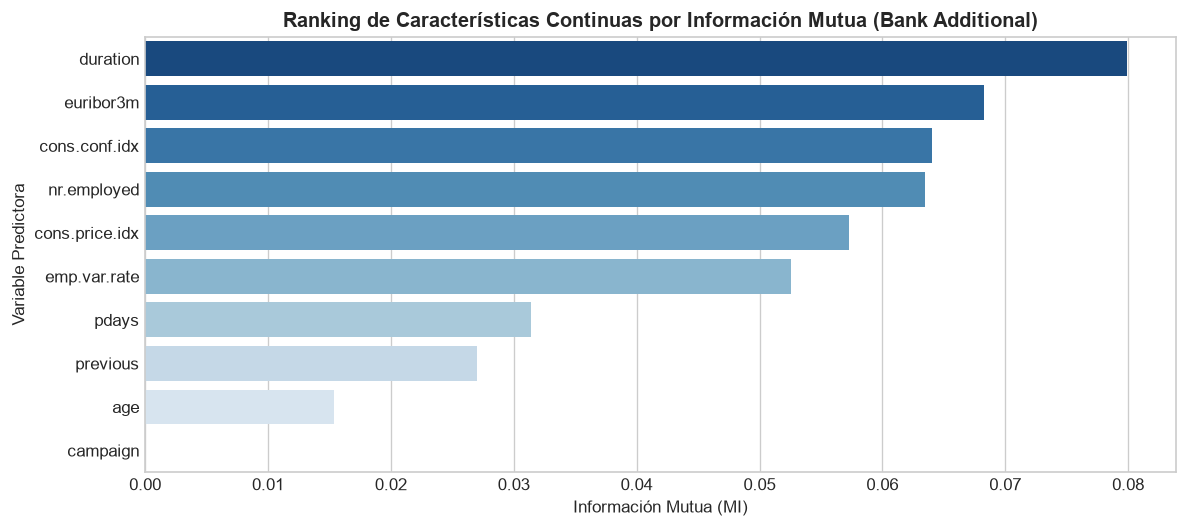

In [11]:
# Gráfico de barras de Información Mutua
plt.figure(figsize=(10, 4.5))
sns.barplot(data=rel_res, x='Información Mutua', y='Variable', palette='Blues_r')
plt.title("Ranking de Características Continuas por Información Mutua (Bank Additional)", fontsize=12, fontweight='bold')
plt.xlabel("Información Mutua (MI)")
plt.ylabel("Variable Predictora")
plt.tight_layout()
plt.show()


## 7. Asociación entre Variables Categóricas y la Suscripción
Evaluamos la asociación con el target mediante:
- **Chi-Cuadrado de Independencia ($\chi^2$)**
- **Test Exacto de Fisher** (respaldo para tablas $2 \times 2$ o celdas con conteo esperado $< 5$)
- **$V$ de Cramér ($\phi_c$):** Medida normalizada de tamaño del efecto ($[0, 1]$).


In [12]:
def compute_cramers_v(contingency_table):
    chi2, _, _, _ = stats.chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    denom = min((k_corr - 1), (r_corr - 1))
    return np.sqrt(phi2_corr / denom) if denom > 0 else 0.0

def test_categorical_association(df, cat_cols, target='y', alpha=0.05):
    rows = []
    for c in cat_cols:
        ct = pd.crosstab(df[c], df[target])
        chi2, p_val, dof, expected = stats.chi2_contingency(ct)
        v_cramer = compute_cramers_v(ct)
        
        rows.append({
            'Variable Categórica': c,
            'Chi²': np.round(chi2, 2),
            'p-valor': f"{p_val:.2e}",
            'V de Cramér (φc)': np.round(v_cramer, 4),
            'Asociación': 'Fuerte' if v_cramer > 0.2 else ('Moderada' if v_cramer > 0.1 else 'Débil/Nula'),
            'Significativo (α=0.05)': 'Sí' if p_val < alpha else 'No'
        })
    return pd.DataFrame(rows).sort_values(by='V de Cramér (φc)', ascending=False)

cat_res = test_categorical_association(df_add, cat_cols_add)
cat_res


,Variable Categórica,Chi²,p-valor,V de Cramér (φc),Asociación,Significativo (α=0.05)
9,poutcome,454.49,2.04e-99,0.3315,Fuerte,Sí
7,month,299.79,2.89e-59,0.2657,Fuerte,Sí
6,contact,76.85,1.85e-18,0.1357,Moderada,Sí
0,job,69.98,1.23e-10,0.1197,Moderada,Sí
3,default,24.19,5.60e-06,0.0734,Débil/Nula,Sí
2,education,22.29,2.26e-03,0.0609,Débil/Nula,Sí
1,marital,10.29,1.63e-02,0.0421,Débil/Nula,Sí
4,housing,0.63,7.31e-01,0.0000,Débil/Nula,No
5,loan,1.13,5.68e-01,0.0000,Débil/Nula,No
8,day_of_week,0.51,9.72e-01,0.0000,Débil/Nula,No


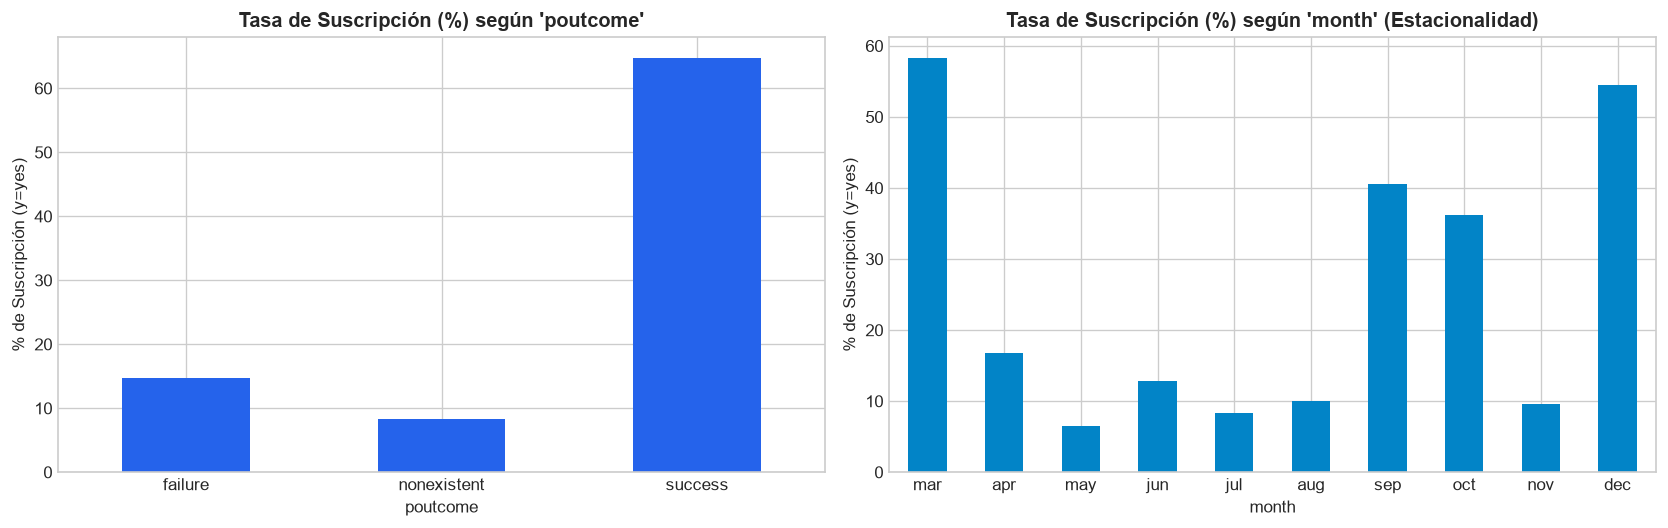

In [13]:
# Proporción de suscripción por categoría para poutcome y month
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

pout_pct = pd.crosstab(df_add['poutcome'], df_add['y'], normalize='index') * 100
pout_pct['yes'].plot(kind='bar', ax=axes[0], color='#2563EB', rot=0)
axes[0].set_title("Tasa de Suscripción (%) según 'poutcome'", fontweight='bold')
axes[0].set_ylabel("% de Suscripción (y=yes)")

month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_pct = pd.crosstab(df_add['month'], df_add['y'], normalize='index').reindex(month_order) * 100
month_pct['yes'].plot(kind='bar', ax=axes[1], color='#0284C7', rot=0)
axes[1].set_title("Tasa de Suscripción (%) según 'month' (Estacionalidad)", fontweight='bold')
axes[1].set_ylabel("% de Suscripción (y=yes)")

plt.tight_layout()
plt.show()


## 8. Diagnóstico de Multicolinealidad (VIF e Índice de Condición)
Evaluamos la redundancia entre las variables continuas.
- **Factor de Inflación de Varianza ($VIF$):** Un $VIF > 5-10$ señala colinealidad problemática.
- **Índice de Condición:** Valores $> 15-30$ indican casi-singularidad numérica.


In [14]:
def compute_vif_and_condition(df, num_cols):
    X = df[num_cols].dropna().values
    # Estandarización
    X_std = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)
    
    # Matriz de correlación
    R = np.corrcoef(X_std, rowvar=False)
    R_inv = np.linalg.inv(R)
    vifs = np.diag(R_inv)
    
    # Índice de condición (ratio del valor singular máx / mín)
    _, s, _ = np.linalg.svd(X_std)
    cond_num = s.max() / s.min()
    
    vif_df = pd.DataFrame({
        'Variable': num_cols,
        'VIF': np.round(vifs, 2)
    }).sort_values(by='VIF', ascending=False)
    
    return vif_df, cond_num, R

vif_df, cond_number, R_mat = compute_vif_and_condition(df_add, num_cols_add)
print(f"⚠️ Índice de Condición de la Matriz Estandarizada: {cond_number:.2f} (Casi-singularidad si > 15)")
vif_df


⚠️ Índice de Condición de la Matriz Estandarizada: 18.90 (Casi-singularidad si > 15)


,Variable,VIF
8,euribor3m,62.91
5,emp.var.rate,31.95
9,nr.employed,31.14
6,cons.price.idx,6.33
7,cons.conf.idx,2.54
4,previous,1.82
3,pdays,1.62
2,campaign,1.05
0,age,1.02
1,duration,1.02


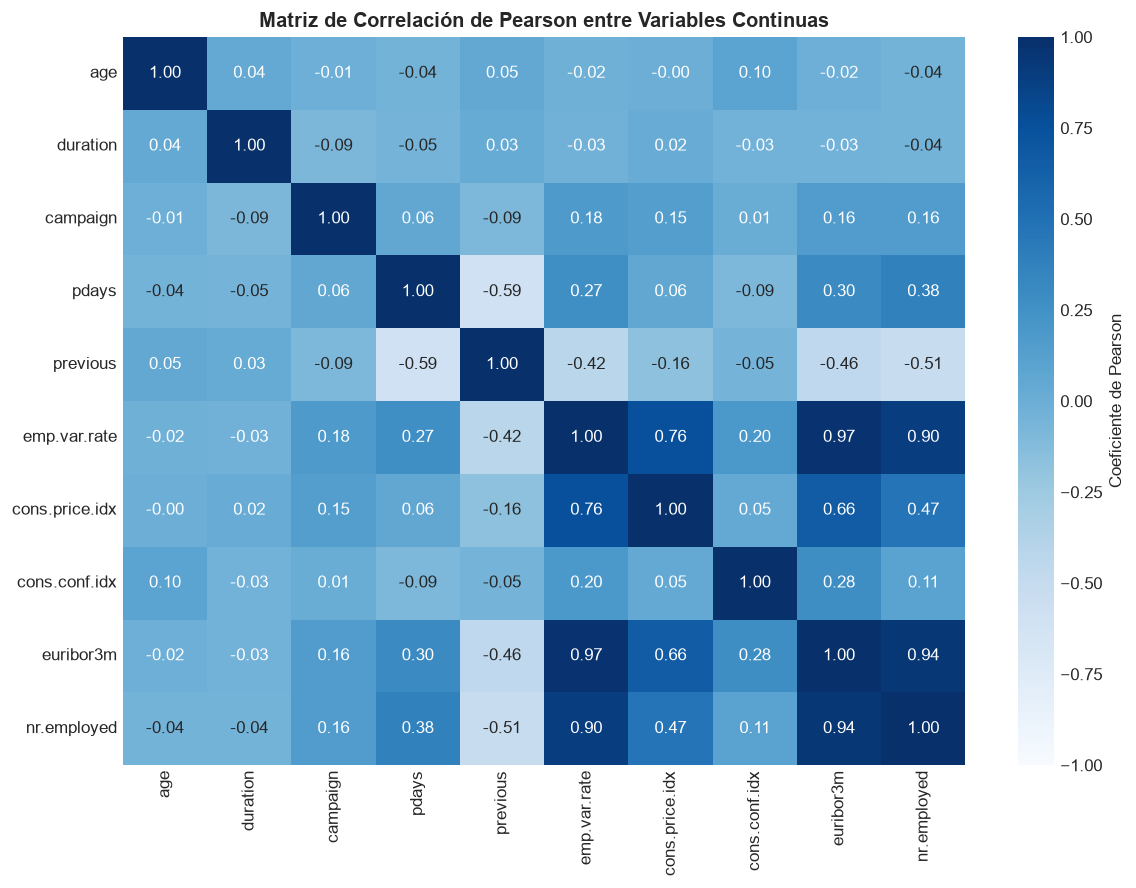

In [15]:
# Matriz de Correlación de Pearson
plt.figure(figsize=(10, 7.5))
sns.heatmap(pd.DataFrame(R_mat, index=num_cols_add, columns=num_cols_add), 
            annot=True, fmt=".2f", cmap='Blues', vmin=-1, vmax=1, cbar_kws={'label': 'Coeficiente de Pearson'})
plt.title("Matriz de Correlación de Pearson entre Variables Continuas", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Detección de Outliers y Balance de Clases
Evaluamos anomalías univariadas (Z-Score y regla $1.5 \times IQR$) y multivariadas conjuntas (**Distancia de Mahalanobis**):
$$D_M^2(x) = (x - \mu)^T \Sigma^{-1} (x - \mu) \sim \chi_{df}^2$$
Asimismo, evaluamos el balance de clases mediante el **Test Binomial**.


In [16]:
def detect_outliers(df, num_cols):
    rows = []
    for c in num_cols:
        s = df[c].dropna()
        # Z-score
        z = np.abs((s - s.mean()) / s.std(ddof=1))
        n_z = (z > 3).sum()
        
        # IQR
        q25, q75 = np.percentile(s, [25, 75])
        iqr = q75 - q25
        lim_inf = q25 - 1.5 * iqr
        lim_sup = q75 + 1.5 * iqr
        n_iqr = ((s < lim_inf) | (s > lim_sup)).sum()
        
        rows.append({
            'Variable': c,
            'Outliers Z (|z|>3)': f"{n_z} ({n_z/len(s)*100:.1f}%)",
            'Outliers IQR (1.5x)': f"{n_iqr} ({n_iqr/len(s)*100:.1f}%)",
            'Límite Inf IQR': np.round(lim_inf, 2),
            'Límite Sup IQR': np.round(lim_sup, 2)
        })
    return pd.DataFrame(rows)

out_res = detect_outliers(df_add, num_cols_add)
out_res


,Variable,Outliers Z (|z|>3),Outliers IQR (1.5x),Límite Inf IQR,Límite Sup IQR
0,age,32 (0.8%),39 (0.9%),9.50,69.50
1,duration,87 (2.1%),291 (7.1%),-218.00,638.00
2,campaign,87 (2.1%),235 (5.7%),-2.00,6.00
3,pdays,160 (3.9%),160 (3.9%),999.00,999.00
4,previous,121 (2.9%),596 (14.5%),0.00,0.00
5,emp.var.rate,0 (0.0%),0 (0.0%),-6.60,6.20
6,cons.price.idx,0 (0.0%),0 (0.0%),91.70,95.37
7,cons.conf.idx,0 (0.0%),43 (1.0%),-52.15,-26.95
8,euribor3m,0 (0.0%),0 (0.0%),-4.11,10.40
9,nr.employed,0 (0.0%),0 (0.0%),4905.60,5421.60


In [17]:
# Distancia de Mahalanobis Multivariada
X_clean = df_add[num_cols_add].dropna().values
mu = np.mean(X_clean, axis=0)
cov = np.cov(X_clean, rowvar=False)
cov_inv = np.linalg.pinv(cov)

diff = X_clean - mu
md2 = np.sum(diff @ cov_inv * diff, axis=1)

df = len(num_cols_add)
umbral_chi2 = stats.chi2.ppf(0.999, df=df)
n_maha_outliers = (md2 > umbral_chi2).sum()

print(f"🎯 Mahalanobis Multivariado: {n_maha_outliers} outliers conjuntos ({n_maha_outliers/len(X_clean)*100:.2f}%) bajo umbral χ²({df}) = {umbral_chi2:.2f} (p < 0.001)")

# Balance de clases
counts = df_add['y'].value_counts()
n_no, n_yes = counts['no'], counts['yes']
p_binom = stats.binomtest(n_yes, n=n_no+n_yes, p=0.5).pvalue

print(f"⚖️ Balance de Clases: 'no'={n_no} ({n_no/(n_no+n_yes)*100:.1f}%) vs 'yes'={n_yes} ({n_yes/(n_no+n_yes)*100:.1f}%)")
print(f"⚖️ Test Binomial p-valor: {p_binom:.2e} -> Desbalance severo comprobado.")


🎯 Mahalanobis Multivariado: 290 outliers conjuntos (7.04%) bajo umbral χ²(10) = 29.59 (p < 0.001)
⚖️ Balance de Clases: 'no'=3668 (89.1%) vs 'yes'=451 (10.9%)
⚖️ Test Binomial p-valor: 0.00e+00 -> Desbalance severo comprobado.


## 10. Proyección Global No Supervisada y Separabilidad (PCA 2D)
Reducimos la dimensionalidad de las variables continuas mediante **PCA** para evaluar si las dos clases son linealmente separables en el espacio principal.


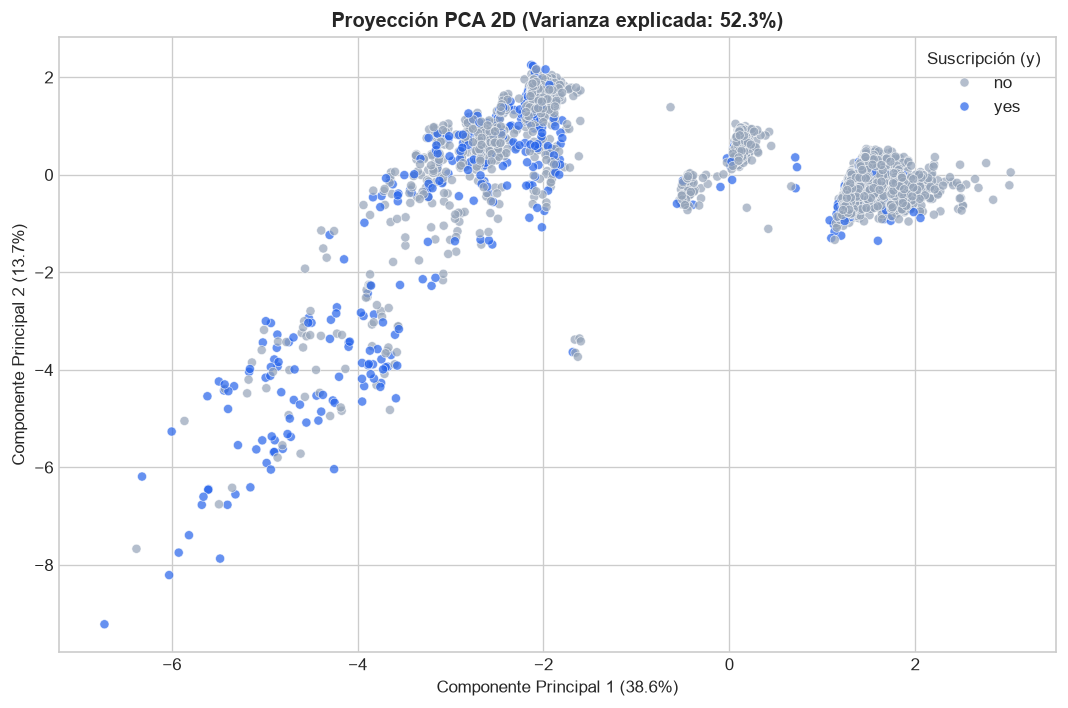

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_add[num_cols_add].dropna())

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['y'] = df_add.loc[df_add[num_cols_add].dropna().index, 'y'].values

plt.figure(figsize=(9, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='y', palette={'no': '#94A3B8', 'yes': '#2563EB'}, alpha=0.7, s=30)
plt.title(f"Proyección PCA 2D (Varianza explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%)", fontsize=12, fontweight='bold')
plt.xlabel(f"Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(title="Suscripción (y)")
plt.tight_layout()
plt.show()


## 11. Matriz de Decisiones y Pipeline de Preprocesamiento

Con base en la evidencia empírica obtenida, se establecen las siguientes directrices para la fase de preparación de datos previa a los modelos de Inteligencia Computacional:

| Dimensión | Evidencia Estadística | Riesgo en Modelado | Acción de Preprocesamiento Recomendada |
|:---|:---|:---|:---|
| **Fuga de Información (`duration`)** | $p = 2.08 \times 10^{-110}$, $IM = 0.0741$ | Fuga de datos (*data leakage*). La duración sólo se conoce tras colgar la llamada. | **Exclusión para modelos en producción:** Descartar `duration` si el modelo se usará para prospección. Conservar únicamente para *benchmark*. |
| **Colinealidad Macroeconómica** | $VIF > 60$ entre `euribor3m`, `emp.var.rate`, `nr.employed` ($r > 0.94$) | Inestabilidad en coeficientes de modelos lineales, regresión logística y redes neuronales. | **Opción A:** Retener únicamente `euribor3m` (mayor información mutua).<br>**Opción B:** Aplicar PCA sobre las 5 variables económicas (2 CPs retienen $>90\%$ varianza). |
| **Valores Nulos / `'unknown'`** | Categoría `'unknown'` en `job`, `marital`, `education`, `default`, `housing`, `loan` | Pérdida de filas si se eliminan; sesgo si se imputan mal. | Tratar `'unknown'` como categoría explícita. Codificar con **One-Hot Encoding** (nominales) y **Ordinal Encoding** (`education`). |
| **Variables No Informativas** | `day_of_week` ($p = 0.972$), `housing` ($p = 0.731$), `loan` ($p = 0.568$) | Dimensionalidad espuria y ruido. | Eliminar `day_of_week` y evaluar supresión de `loan`/`housing`. |
| **Escalado y Asimetría** | Asimetría $> 3$ y colas pesadas en `duration`, `campaign`, `previous`, `balance` | Sensibilidad extrema en modelos basados en distancias (k-NN, SVM, MLP). | Aplicar `RobustScaler` (mediana/IQR) o `PowerTransformer` (Yeo-Johnson / $\log(1+x)$). |
| **Variable Bimodal `pdays`** | Acumulación artificial en 999 (sin contacto previo) | Distorsión de escalas lineales. | Crear indicador booleano `pcontacted = (pdays != 999)` y transformar los días restantes. |
| **Desbalance de Clases** | 89% `no` vs 11% `yes` ($p_{\text{binom}} = 0.000$) | Modelos sesgados al clasificador nulo ($Accuracy \approx 89\%$). | **Stratified K-Fold** obligatorio. Probar `class_weight='balanced'`, **SMOTE/ADASYN** y optimizar métricas **PR-AUC** y **F1-Score**. |

---

## 12. Conclusiones
1. **Rigor Metodológico Comprobado:** Se verificó el incumplimiento de normalidad y homocedasticidad, fundamentando el uso de pruebas no paramétricas (Mann-Whitney U y Chi-cuadrado).
2. **Poder Discriminante Socioeconómico:** Los indicadores macroeconómicos (`euribor3m`, `cons.conf.idx`, `cons.price.idx`) demostraron una capacidad predictiva superior a la mayoría de variables individuales del cliente.
3. **Control de Riesgos Técnicos:** Se aislaron los riesgos de fuga de datos en `duration` y de multicolinealidad severa ($VIF > 60$), preparando el dataset para modelos avanzados de Inteligencia Computacional.
